In [1]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv('/content/sample_data/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [20]:
pd.read_sql(query, conn)

,rating,total
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


In [3]:
conn = sqlite3.connect('netflix.db')
cursor = conn.cursor()

In [4]:
df.to_sql('netflix_content', conn, if_exists='replace', index=False)

5398

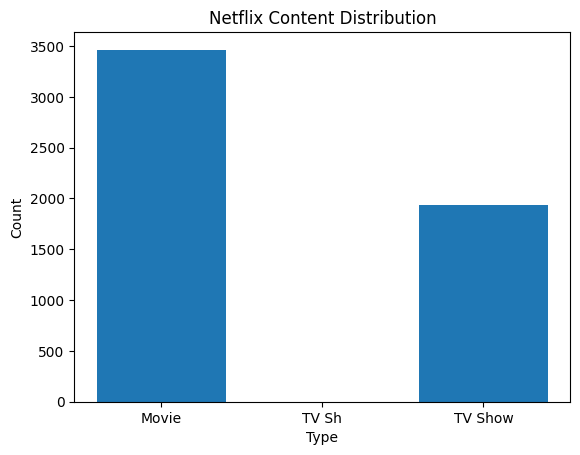

In [10]:
import matplotlib.pyplot as plt

query = """
SELECT type, COUNT(*) as total
FROM netflix_content
GROUP BY type
"""

data = pd.read_sql(query, conn)

plt.bar(data['type'], data['total'])
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Netflix Content Distribution")
plt.show()

In [13]:
import pandas as pd
import sqlite3

df = pd.read_csv('/content/sample_data/netflix_titles.csv')

conn = sqlite3.connect('netflix_analytics.db')

df.to_sql('netflix_content', conn, if_exists='replace', index=False)

print("Database created successfully")

Database created successfully


In [16]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('netflix_analytics.db')

query = "SELECT * FROM netflix_content LIMIT 5"

pd.read_sql(query, conn)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,None,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,None,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",None,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,None,None,None,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,None,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [17]:
query = """
SELECT type, COUNT(*) AS total
FROM netflix_content
GROUP BY type
"""

pd.read_sql(query, conn)

,type,total
0,Movie,6131
1,TV Show,2676


In [18]:
query = """
SELECT country, COUNT(*) AS total
FROM netflix_content
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,country,total
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [19]:
query = """
SELECT rating, COUNT(*) AS total
FROM netflix_content
GROUP BY rating
ORDER BY total DESC
"""

pd.read_sql(query, conn)

,rating,total
0,TV-MA,3207
1,TV-14,2160
2,TV-PG,863
3,R,799
4,PG-13,490
5,TV-Y7,334
6,TV-Y,307
7,PG,287
8,TV-G,220
9,NR,80


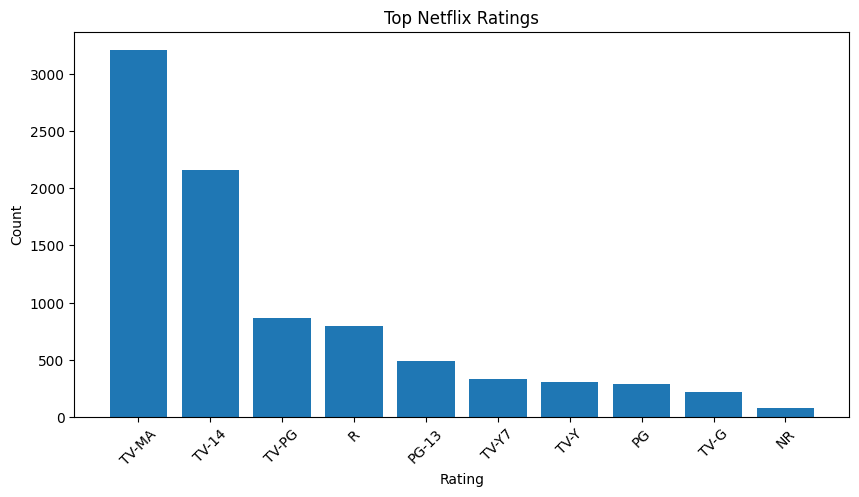

In [22]:
query = """
SELECT rating, COUNT(*) as total
FROM netflix_content
WHERE rating IS NOT NULL
GROUP BY rating
ORDER BY total DESC
LIMIT 10
"""

data = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
plt.bar(data['rating'], data['total'])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Top Netflix Ratings")
plt.xticks(rotation=45)
plt.show()

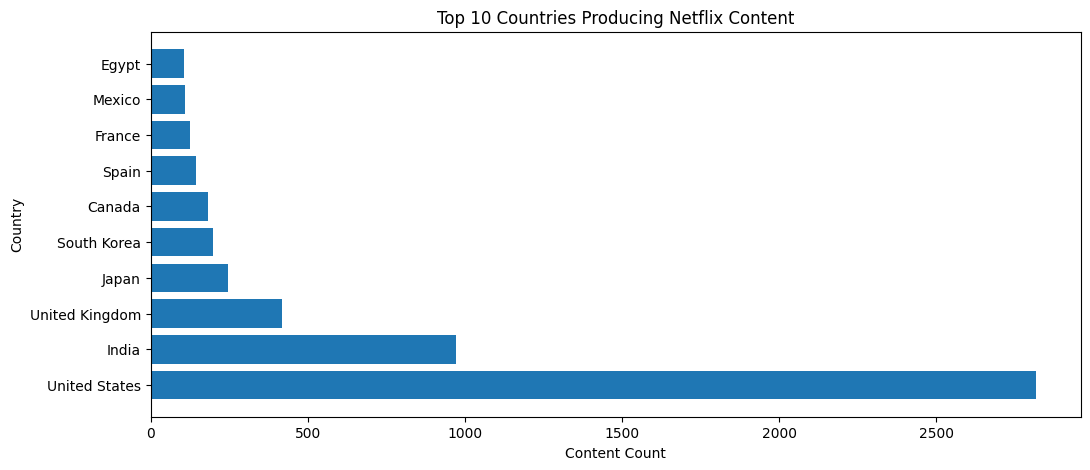

In [23]:
query = """
SELECT country, COUNT(*) as total
FROM netflix_content
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total DESC
LIMIT 10
"""

data = pd.read_sql(query, conn)

plt.figure(figsize=(12,5))
plt.barh(data['country'], data['total'])
plt.xlabel("Content Count")
plt.ylabel("Country")
plt.title("Top 10 Countries Producing Netflix Content")
plt.show()

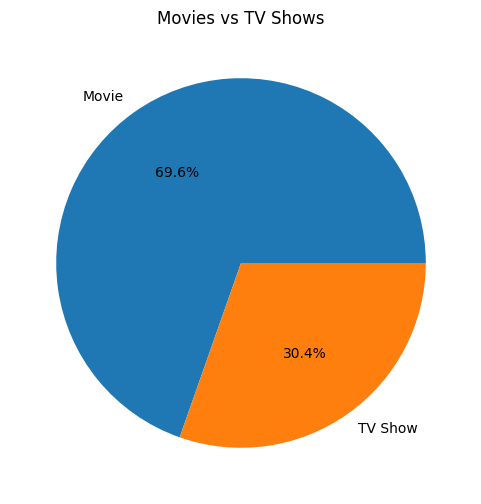

In [24]:
query = """
SELECT type, COUNT(*) as total
FROM netflix_content
GROUP BY type
"""

data = pd.read_sql(query, conn)

plt.figure(figsize=(6,6))
plt.pie(data['total'], labels=data['type'], autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()